<div>
    <h2 style="color: green; font-weight: bold;">PyTorch Training Workflow</h2>
    <ol>
        <li>Load the data</li>
        <li>Convert data to Tensors</li>
        <li>Create <code>TensorDataset</code> &amp; <code>DataLoader</code></li>
        <li>Define ANN model</li>
        <li>Train the model</li>
        <li>Save model</li>
        <li>Evaluate</li>
    </ol>
</div>


<h4 style="color:yellow"> 1. Load the Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


<h5> AT => Temperature
<h5> V &nbsp; => Vaccume
<h5> AP => Pressure
<h5> RH => Humidity

<h5> PE => Produced Energy

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

<h4 style="color:yellow"> 2. Convert data to Tensors

<h5> Split out data

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
df.shape

(9568, 5)

<h5> Scale data

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [9]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

<h4 style="color: yellow"> 3. Create <code style= "color:yellow">TensorDataset</code> &amp; <code style="color: yellow">DataLoader</code>


In [10]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

<h4 style="color: Yellow"> 4. Define ANN model

<h5> Deep Learning Start

In [12]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
            # Output layer
            nn.Linear(6, 1),
        )

    def forward(self, X):
        return self.model(X)

In [13]:
import torch.optim as optim

model = ANN()

# Loss, Optimizer

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

<h4 style="color:Yellow"> 5. Training and Testing ANN Model

In [14]:
# Train the ANN

train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()

    # total training loss of 1 epoch
    running_loss = 0.0

    for xb, yb in train_loader:
        # xb= features of 1 batch
        # yb= labels of 1 batch
        optimizer.zero_grad()

        # forward propagation
        # predicted outputs for this batch
        outputs = model(xb)

        # compute loss
        loss = crietrion(outputs, yb)

        # backward propagation
        loss.backward()

        # update parameters
        optimizer.step()

        # loss is tensor
        # convert tensor to float by .item()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    # no gradients computr
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 205787.65384114583 & val loss = 203440.109375
epoch 2/100 ==> train loss = 195479.51399739584 & val loss = 182622.890625
epoch 3/100 ==> train loss = 160310.1931966146 & val loss = 134039.3125
epoch 4/100 ==> train loss = 104127.26140950521 & val loss = 75704.7109375
epoch 5/100 ==> train loss = 53800.15321451823 & val loss = 37388.1015625
epoch 6/100 ==> train loss = 28452.82195638021 & val loss = 22822.349609375
epoch 7/100 ==> train loss = 19695.57196451823 & val loss = 17471.9921875
epoch 8/100 ==> train loss = 15609.450988769531 & val loss = 13963.5380859375
epoch 9/100 ==> train loss = 12441.798309326172 & val loss = 10882.4443359375
epoch 10/100 ==> train loss = 9477.994667561848 & val loss = 8066.77685546875
epoch 11/100 ==> train loss = 6858.573791503906 & val loss = 5649.09619140625
epoch 12/100 ==> train loss = 4673.148944091797 & val loss = 3775.8935546875
epoch 13/100 ==> train loss = 3039.204205322266 & val loss = 2465.87744140625
epoch 14/100

<h5> Visualize Losses

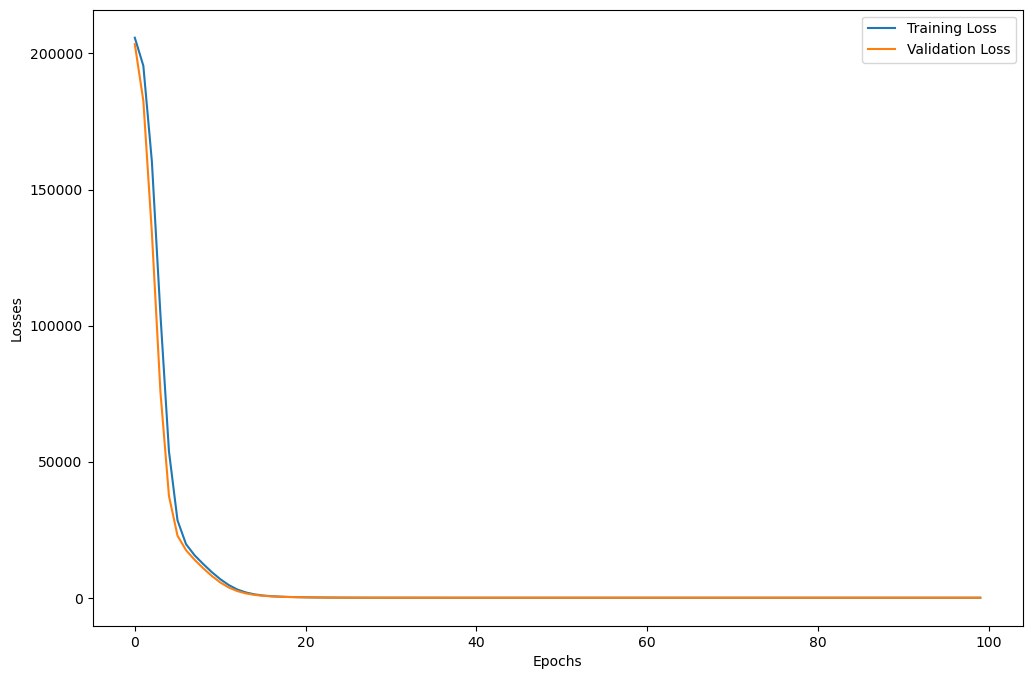

In [15]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({"Training Loss": train_losses, "Validation Loss": val_losses})

plt.figure(figsize=(12, 8))
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

<h5 style="color:yellow"> 6. Loading the best model

In [16]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

<h5 style="color:yellow" > 7. Evaluate the model

<ol>
        <li>Training MSE</li>
        <li>Testing MSE</li>
        <li>R2 Score</li>
    </ol>

In [17]:
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.051740646362305
Testing MSE: 19.52422523498535


In [18]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9317678705802359


In [19]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.383728,433.27
1,436.925812,438.16
2,460.909698,458.42
3,475.943573,480.82
4,435.198517,441.41
...,...,...
1909,451.263031,456.70
1910,431.610748,438.04
1911,467.896332,467.80
1912,431.064484,437.14
